In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:/Users/Sagar Sharma/OneDrive/Documents/dsbdal assignments/assignment2/academic_performance_50.csv")
df.head()


,Student_ID,Age,Gender,Attendance_Percentage,Study_Hours_per_Week,Math_Score,Science_Score,English_Score
0,1,23,Male,96.34,13.05,57.01,50.95,53.25
1,2,21,male,101.48,5.76,78.11,72.71,71.55
2,3,22,FEMALE,83.74,14.29,61.48,62.12,74.03
3,4,18,FEMALE,NaN,4.58,52.65,71.55,71.32
4,5,19,male,67.71,6.23,69.91,89.93,69.96


In [3]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Attendance_Percentage    1
Study_Hours_per_Week     1
Math_Score               1
Science_Score            0
English_Score            0
dtype: int64

In [4]:
numerical_cols = df.select_dtypes(include="number").columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [5]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Attendance_Percentage    0
Study_Hours_per_Week     0
Math_Score               0
Science_Score            0
English_Score            0
dtype: int64

In [6]:
df["Gender"].value_counts()

Gender
FEMALE    15
Male      12
Female    12
male      11
Name: count, dtype: int64

In [7]:
df["Gender"] = df["Gender"].str.lower()
df["Gender"] = df["Gender"].replace({
    "m":"male",
    "f":"female"
})

In [8]:
df["Gender"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [9]:
df["Gender"] = df["Gender"].map({'male':0, 'female':1})

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

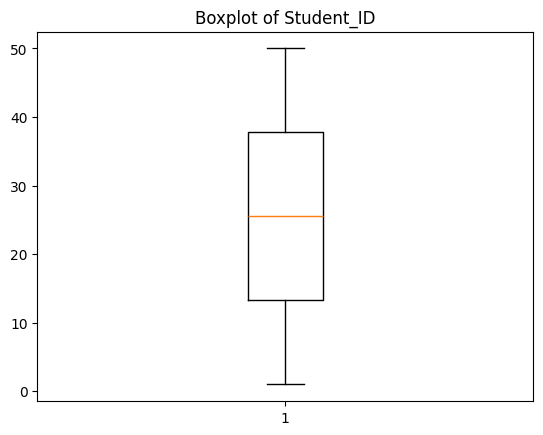

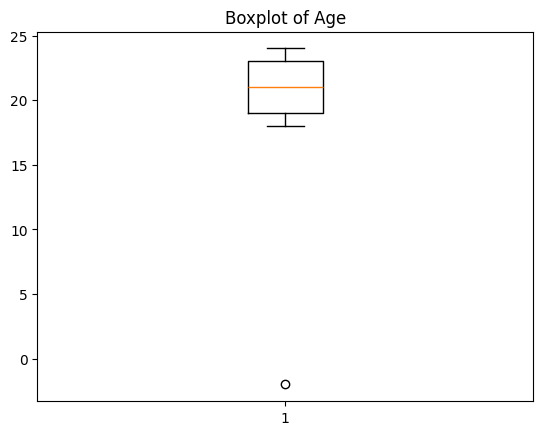

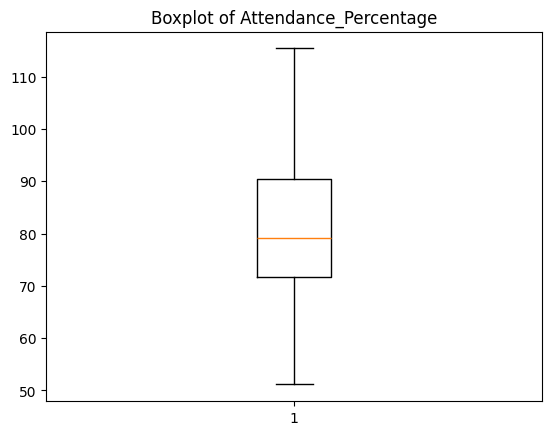

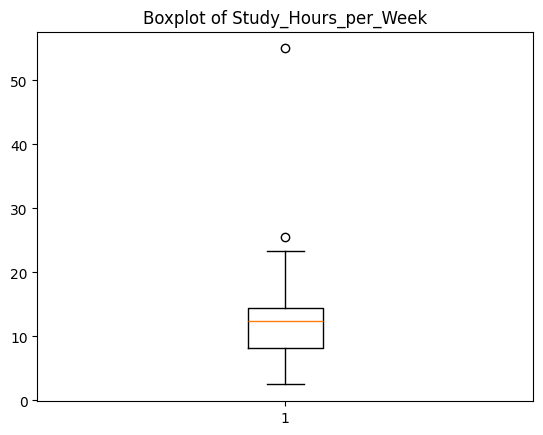

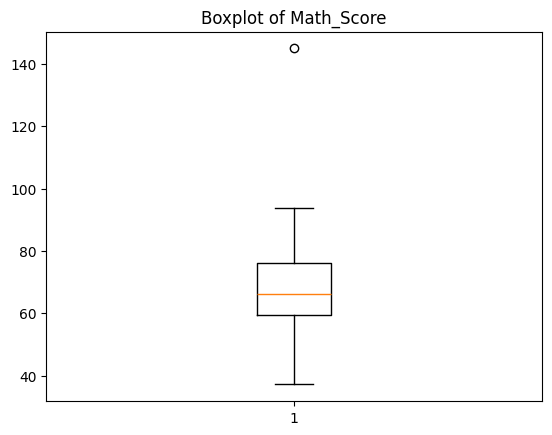

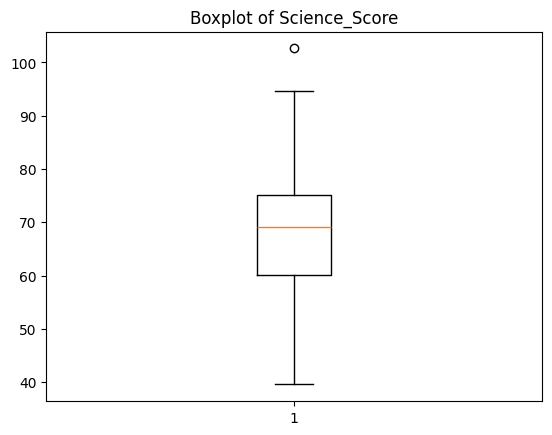

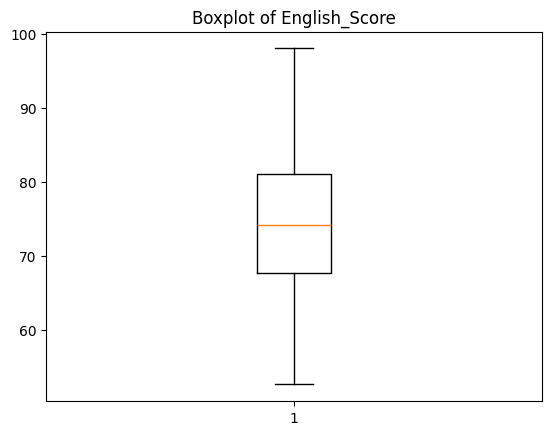

In [11]:
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [12]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower,upper)

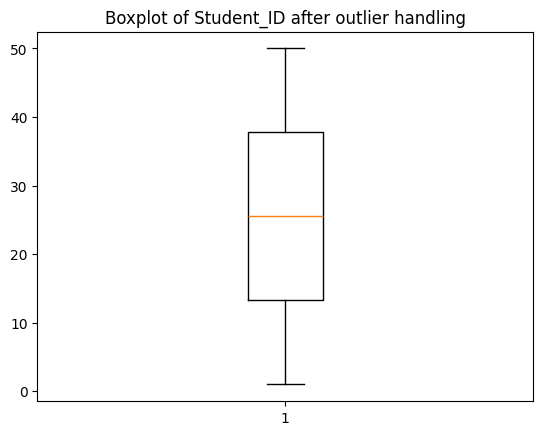

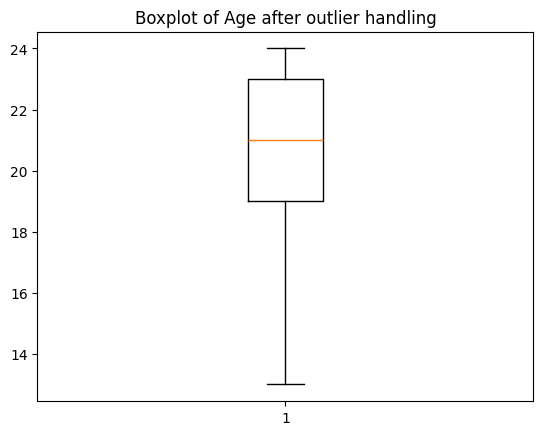

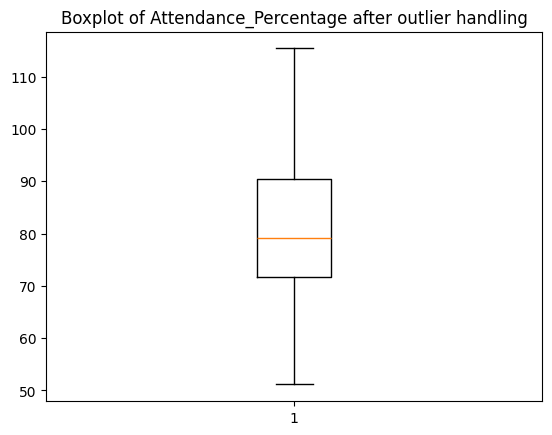

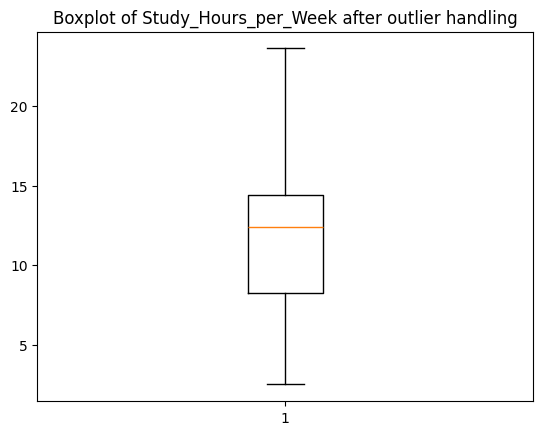

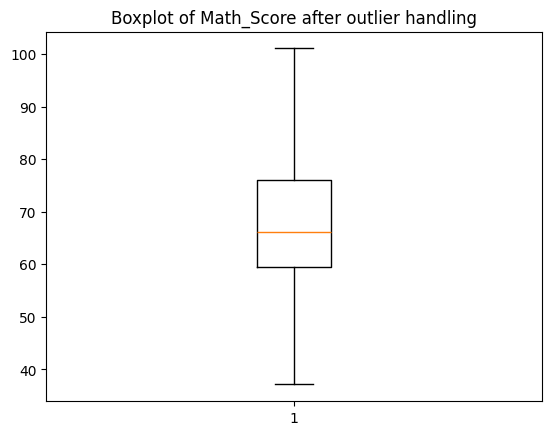

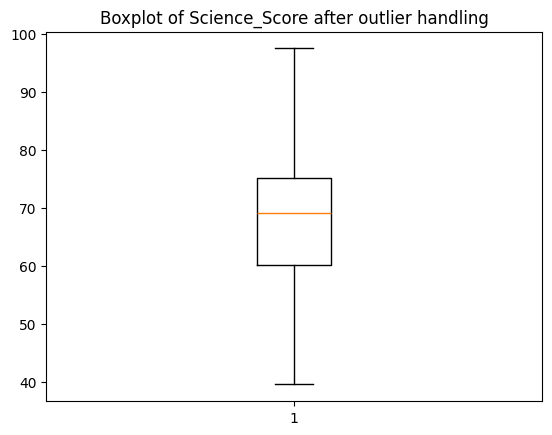

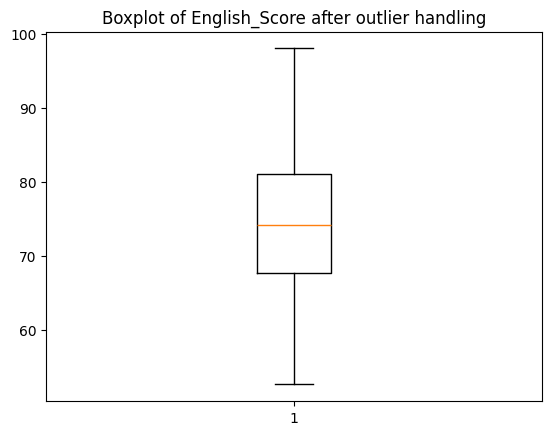

In [13]:
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col} after outlier handling")
    plt.show()

In [15]:
df["Math_Scaled"] = (df["Math_Score"] - df["Math_Score"].min())/(df["Math_Score"].max() - df["Math_Score"].min())

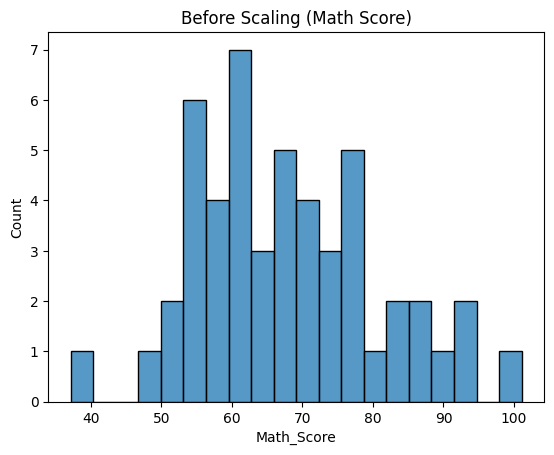

In [17]:
plt.figure()
sns.histplot(df["Math_Score"], bins=20)
plt.title("Before Scaling (Math Score)")
plt.show()

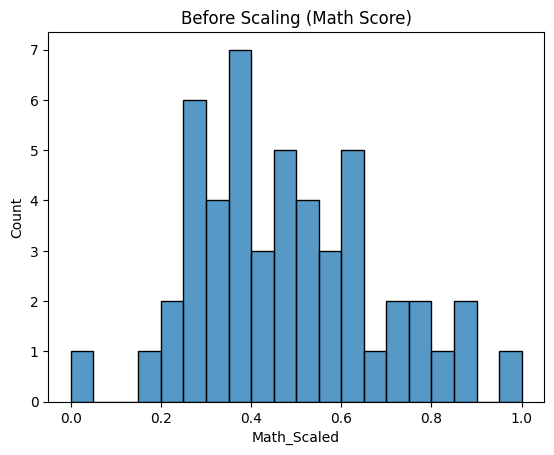

In [18]:
plt.figure()
sns.histplot(df["Math_Scaled"], bins=20)
plt.title("Before Scaling (Math Score)")
plt.show()

In [19]:
df["Math_Score"].skew()

np.float64(0.4221699327699754)

In [20]:
df["Math_log"] = np.log1p(df["Math_Score"])

In [21]:
df["Math_log"].skew()

np.float64(-0.18104918996166627)

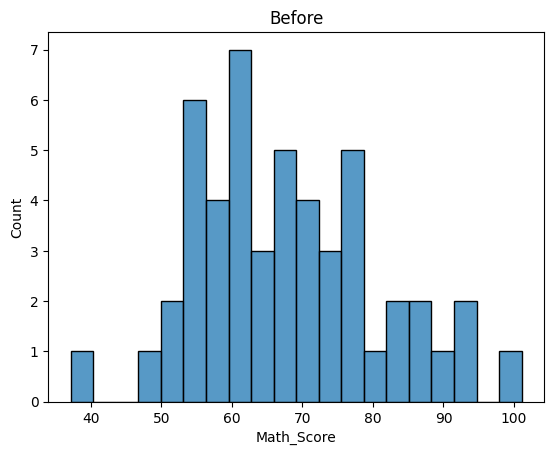

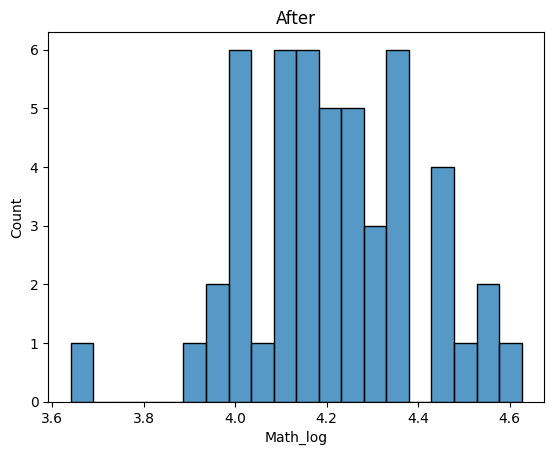

In [22]:
plt.figure()
sns.histplot(df["Math_Score"], bins=20)
plt.title("Before")
plt.show()

plt.figure()
sns.histplot(df["Math_log"], bins=20)
plt.title("After")
plt.show()